In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm  
from data_fitting.module_fitzcu import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp
from yamltool import yml_comment

In [4]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.212"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_sg_int4_v2 - envelope memory 16384 samples (38.095 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 3

# System Config

In [11]:
r=6057
f_ge = 4683


In [20]:

config = {
    ## Channel Params. ##
    'res_ch': 0,
    'ro_ch': 0,
    'qubit_ch': 14,
    'flux':9,
    ## Res Pulse Params. ##
    'f_res': r, # [MHz]
    'res_len': 5, # [us]
    'res_phase': 0, # [deg]
    'res_gain': 0.55, # [DAC units]

    ## Readout Params. ##
    'trig_time': 0.46, # [us]
    'ro_len': 2.9, # [us]
    'relax_delay': 50, # [us]

    ## Qubit Params. ##
    'qb_pulse_style': 'arb',
    'f_ge': f_ge, # [MHz]
    'nqz':2,
    'qubit_gain': 1,
    'probe_len': 5, # [us]
    'flat_top_len':2, # [us]
    "pi_gain":  0.001, # [DAC units]
    "pi2_gain": 0.001, # [DAC units]
    'qubit_phase': 0,
    'sigma': 0.1/5,
    'ramsey_freq': 3, # [MHz]
     }

  0%|          | 0/500 [00:00<?, ?it/s]

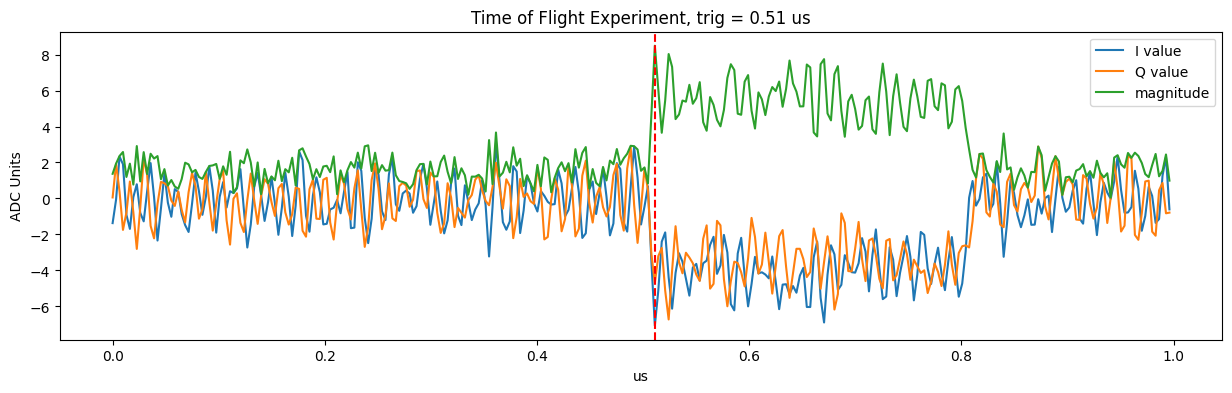

In [13]:
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']

        self.declare_gen(ch=res_ch, nqz=2)

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="myconst", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="myconst", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)



config.update({'trig_time' : 0, 'res_len': 0.3, 'ro_len':1, 'res_gain': 0.5, 'f_res':6000, 'res_ch':0})

###################
# Run the Program
###################
pyavg = 500

prog =LoopbackProgram(soccfg, reps=1, final_delay=config['relax_delay'], cfg=config)
iq_list = prog.acquire_decimated(soc, soft_avgs=pyavg)
t = prog.get_time_axis(ro_index=0)

# Plot results.
mean=np.mean(np.abs(iq_list[0].dot([1,1j])))


plt.figure(figsize=(15,4))
plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("ADC Units")
plt.xlabel("us")

######## SET THIS VALUE AS YOUR config['trig_time'] #########
# plt.axvline(0.5, c='r') 
plt.axvline(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 1.78*mean)], c='r', ls='--')
plt.title(f'Time of Flight Experiment, trig = {round(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 1.78*mean)],2)} us')
config['trig_time'] = round(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 1.78*mean)],2)

# OneTone

In [14]:
## Using the Dynamically Configured Readout Channel ##
class SingleToneSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [48]:

START_FREQ = r - 5 # [MHz]
STOP_FREQ =  r + 5 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.1
}
run_cfg = {**config, **exp_cfg}


  0%|          | 0/50 [00:00<?, ?it/s]

6056.16

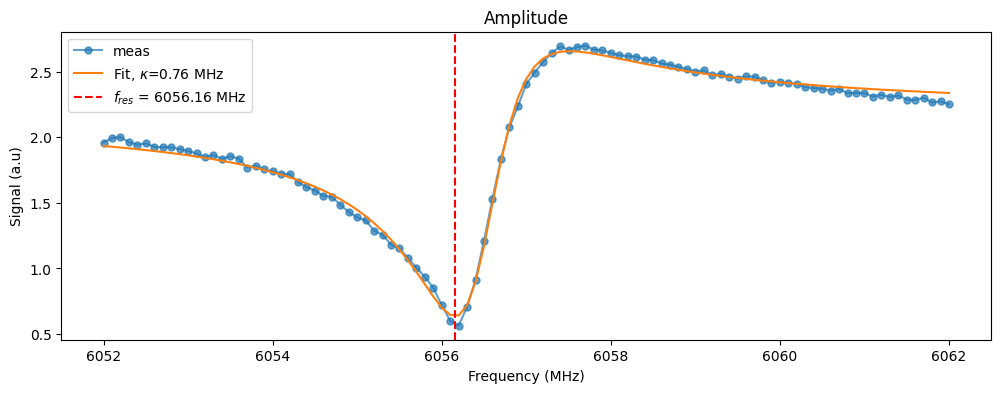

In [49]:
pyavg = 50

prog = SingleToneSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

f_res = resonator_analyze(freqs, res_onetone)
config['f_res'] = f_res
f_res

## Punch Out

In [10]:
class SingleTonePunchoutProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["g_steps"])
        self.add_loop("freqloop", cfg["f_steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [15]:
START_FREQ = r - 3 # [MHz]
STOP_FREQ = r + 3 # [MHz]
STEPS_freq = 31

START_gain = 0.002 # [au]
STOP_gain = 0.1 # [au]
STEPS_gain = 31


expt_cfg = {
    ## Sweep Params: ##
    'f_steps': STEPS_freq, 
    'g_steps': STEPS_gain, 

    ## Resonator Pulse Params. ##
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': QickSweep1D('gainloop', START_gain, STOP_gain), # [DAC units]
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/20 [00:00<?, ?it/s]

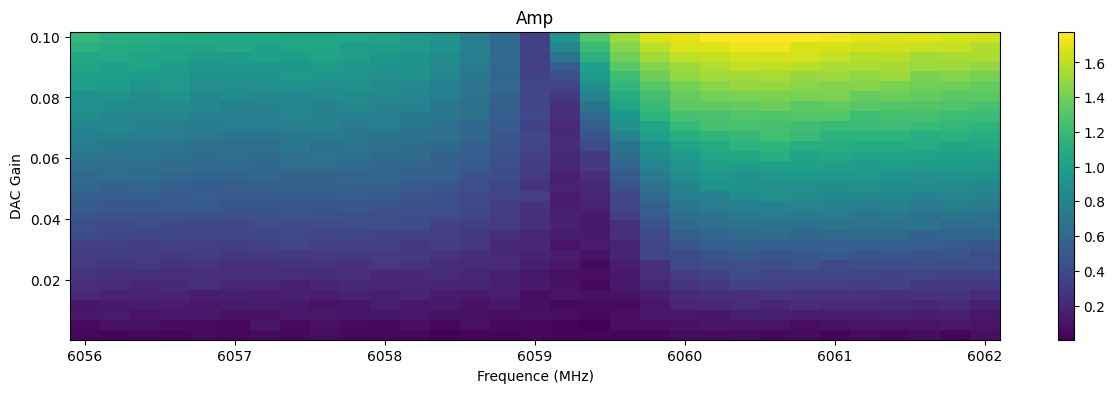

In [16]:
pyavg = 20

prog = SingleTonePunchoutProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
gains = prog.get_pulse_param("res_pulse", "gain", as_array=True)
res_punchout = iq_list[0][0].dot([1,1j])


avg_abs, avg_angle = np.abs(res_punchout), np.angle(res_punchout)

plt.figure( figsize=(15,4))
plt.title('Resonaotr Punch Out')
plt.pcolormesh(freqs, gains, avg_abs, shading="Auto")
plt.ylabel("DAC Gain")
plt.xlabel("Frequence (MHz)")
plt.title("Amp")
plt.colorbar()

# TwoTone

In [50]:
class PulseProbeSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [66]:
cemter = 4100

START_FREQ = cemter - 300# [MHz]
STOP_FREQ = cemter + 300  # [MHz]
STEPS = 200 
config.update({'qmixer_freq':cemter, 'qubit_gain':0.5, 'res_gain':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/10 [00:00<?, ?it/s]

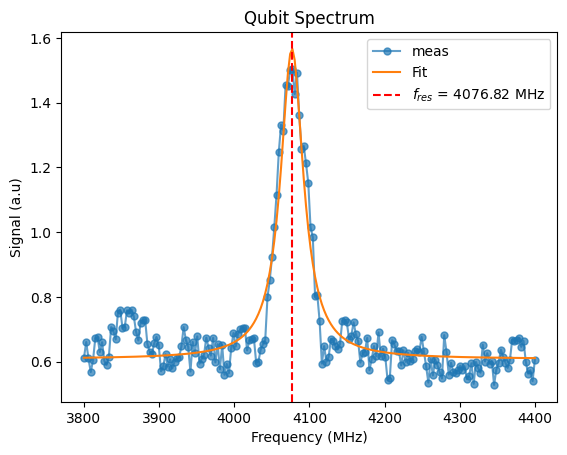

In [67]:
pyavg = 10
qspec=PulseProbeSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)

f_ge = spectrum_analyze(freqs, (iq_list[0][0].dot([1,1j])))
config['f_ge'] = f_ge
config['qmixer_freq']=f_ge

In [68]:
class PulseProbeSpectroscopyProgramflux(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        flux_ch = cfg['flux']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        if soccfg['gens'][flux_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=flux_ch, nqz=1, mixer_freq=0)
        else:
            self.declare_gen(ch=flux_ch, nqz=1)

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_loop("fluxloop", cfg["steps2"])
        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )
        self.add_pulse(ch=flux_ch, name="flux_pulse",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=0,
                       phase= 0,
                       gain=cfg['flux_gain'],
                      )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["flux"], name="flux_pulse", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [63]:
cemter = f_ge

START_FREQ = cemter - 100# [MHz]
STOP_FREQ = cemter + 100  # [MHz]
STEPS = 200 
config.update({'qmixer_freq':cemter, 'qubit_gain':0.3, 'res_gain':0.1, 'probe_len':0.02})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'steps2': 10, # Number of sweep points
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'flux_gain':QickSweep1D('fluxloop', -1, 1)
     }

run_cfg = {**config, **expt_cfg}

In [64]:
pyavg = 20
qspec=PulseProbeSpectroscopyProgramflux(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)
gain = qspec.get_pulse_param('flux_pulse', "gain", as_array=True)

  0%|          | 0/20 [00:00<?, ?it/s]

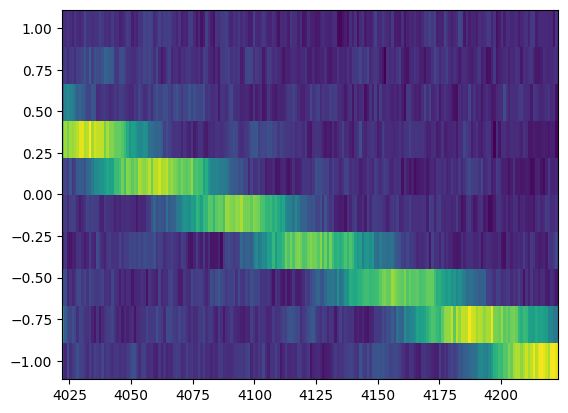

In [65]:
plt.pcolor(freqs, gain, np.abs(iq_list[0][0].dot([1,1j])))

## SNR optimize

In [811]:
class SNR(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [812]:
cemter = r

START_FREQ = cemter - 5# [MHz]
STOP_FREQ = cemter + 5  # [MHz]
STEPS = 200

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    ## Qubit Params. ##
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }

run_cfg = {**config, **expt_cfg}

In [813]:
pyavg = 50
snr=SNR(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = snr.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = snr.get_pulse_param('res_pulse', "freq", as_array=True)

run_cfg['qubit_gain']=0
snr_ref=SNR(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list_ref = snr_ref.acquire(soc, soft_avgs=pyavg, progress=True)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

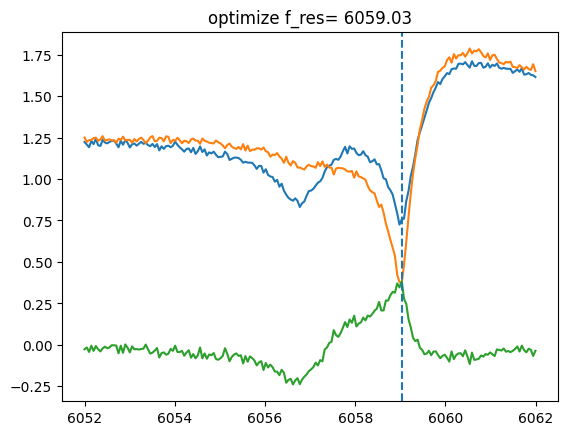

In [814]:
freqs = snr.get_pulse_param('res_pulse', "freq", as_array=True)
plt.plot(freqs, np.abs(iq_list[0][0].dot([1,1j])))
plt.plot(freqs, np.abs(iq_list_ref[0][0].dot([1,1j])))
plt.plot(freqs, np.abs(iq_list[0][0].dot([1,1j])) - np.abs(iq_list_ref[0][0].dot([1,1j])))

sig = np.abs(iq_list[0][0].dot([1,1j])) - np.abs(iq_list_ref[0][0].dot([1,1j]))
if abs(np.argmax(sig))>np.argmin(sig):
    idx = np.argmax(sig)
else:
    idx = np.argmin(sig)
plt.axvline(freqs[idx], ls='--')
plt.title(f'optimize f_res= {freqs[np.argmax(sig)]:.2f}')
config['f_res'] = freqs[np.argmax(sig)]

# Power Rabi

In [80]:
class AmplitudeRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [81]:
START_GAIN = 0.01 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 50


config.update({'relax_delay':50, 'qb_pulse_style':'arb', 'sigma':0.05, 'flat_top_len':0.1, 'nzq':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain":QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/25000 [00:00<?, ?it/s]

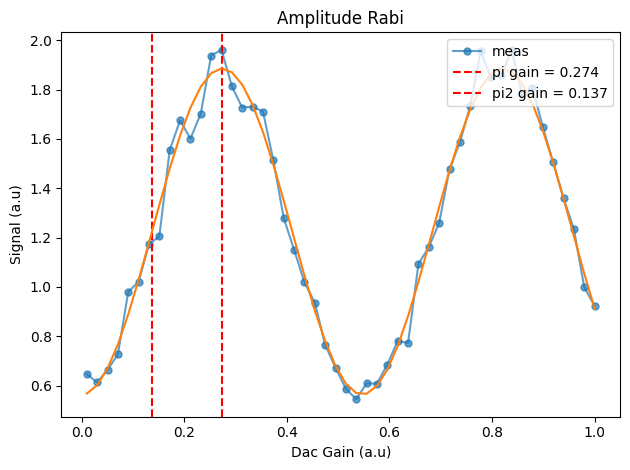

In [82]:
pyavg = 1
run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=500, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True)
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], config['pi2_gain'] = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=None)

In [791]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 50


config.update({'relax_delay':50, 'qb_pulse_style':'arb', 'sigma':0.02, 'flat_top_len':0.1, 'nzq':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain":QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

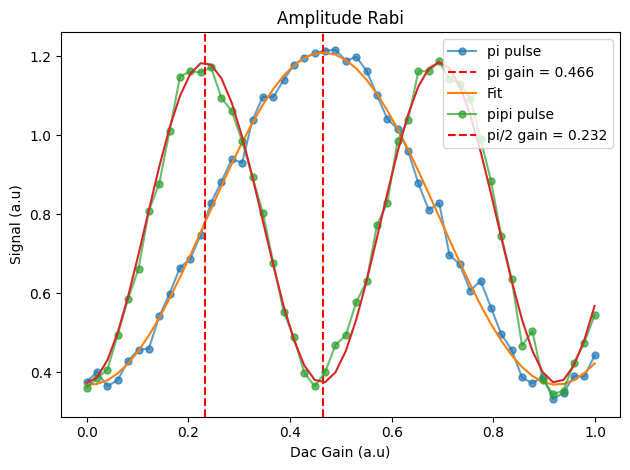

In [792]:
pyavg = 20
run_cfg = {**config, **expt_cfg}

run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

run_cfg['rabi_protocal']='pipi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi2 = iq_list[0][0].dot([1,1j])
config['pi2_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

In [771]:
f_ge = config['f_ge']

# Ramsey

In [83]:
class RamseyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_loop("waitloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp",
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)  
        
        self.delay_auto(cfg['wait_time'], tag='wait') 
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  

        self.delay_auto(0.05) 
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) 
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [84]:
START_TIME = 0. # [us]
STOP_TIME = 5 # [us]
STEPS = 100

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'ramsey_freq':2
     }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/20 [00:00<?, ?it/s]

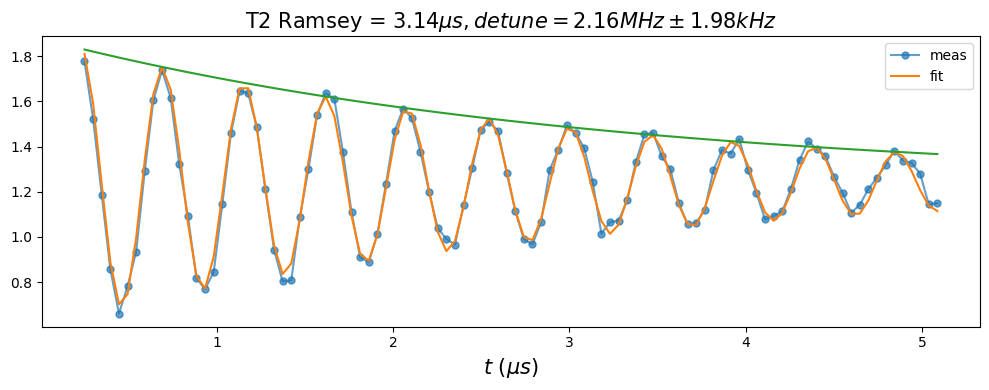

In [85]:
pyavg = 20

ramsey=RamseyProgram(soccfg, reps=100, initial_delay=0.1 ,final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = ramsey.acquire(soc, soft_avgs=pyavg, progress=True)
delay_times = ramsey.get_time_param('wait', "t", as_array=True)
ramsey = iq_list[0][0].dot([1,1j])

t2r = T2fring_analyze(delay_times, ramsey, prefix='Ramsey')

In [79]:
activate_correct=True
if activate_correct:
    if abs(t2r[1]-run_cfg['ramsey_freq'])>0.05:
        config['f_ge'] = config['f_ge']-round((t2r[1]-run_cfg['ramsey_freq']),2)
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),2)}')
    else:
        pass

over detune 2.16


# Echo

In [64]:
class SpinEchoProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'],
                       freq=cfg['f_res'],
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase']+ cfg['wait_time']*360*cfg['ramsey_freq'], 
                        gain=cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'], 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi2_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'], 
                           gain=cfg['pi2_gain'],
                          )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait1') # wait_time after last pulse (wait / 2)
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse_pi", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait2') # wait_time after last pulse (wait / 2)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  #play pulse

        self.delay_auto(0.01) # wait_time after last pulse
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [65]:
START_TIME = 0.0 # [us]
STOP_TIME = 5 # [us]
STEPS = 200

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ramsey_freq':2,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    }

run_cfg = {**config, **expt_cfg}


  0%|          | 0/50 [00:00<?, ?it/s]

Attempted to init fitparam 1 to 8.386559999999985, which is out of bounds 0.02161206030150754 to 6.483618090452262. Instead init to 3.2526150753768848


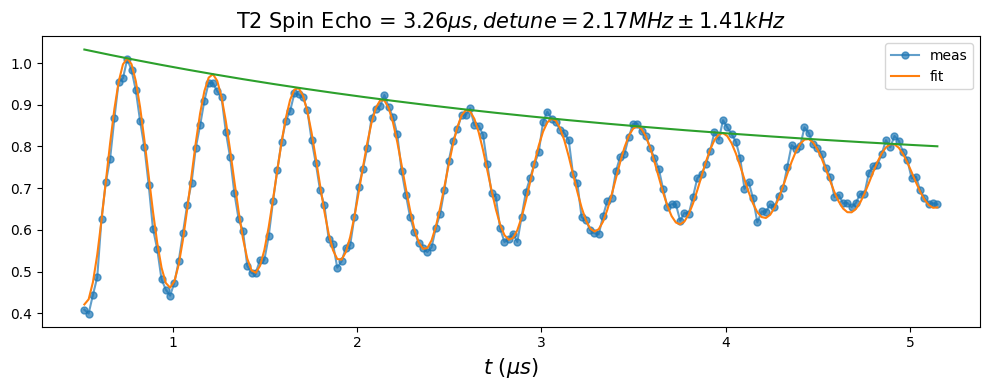

In [66]:
pyavg = 50

spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = spinecho.acquire(soc, soft_avgs=pyavg, progress=True)
delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
spinecho = iq_list[0][0].dot([1,1j])

t2e = T2fring_analyze(delay_times1+delay_times2, spinecho,  prefix='Spin Echo')


# T1

In [86]:
class T1Program(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)


        self.add_loop("waitloop", cfg["steps"])
        
        self.add_gauss(ch=res_ch, name="gaus", sigma=0.008, length=0.008*5, even_length=True,)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope='gaus',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse

        self.delay_auto(cfg['wait_time']+0.01, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [87]:
START_TIME = 0.0 # [us]
STOP_TIME = 30.0 # [us]
STEPS = 30

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay': 50
    }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/150000 [00:00<?, ?it/s]

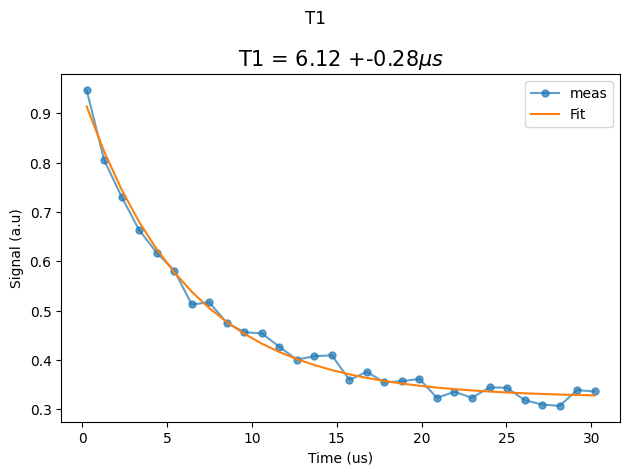

In [88]:
pyavg = 1
T1=T1Program(soccfg, reps=5000, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=True)
delay_times = T1.get_time_param('wait', "t", as_array=True)

t1 = T1_analyze(delay_times, np.abs(iq_list[0][0].dot([1,1j])))

# EF spectrum

In [596]:
## Using the Dynamically Configured Readout Channel ##
class SingleToneSpectroscopyProgramEF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )


    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['qubit_ch'], name="qubit_pulse", t=0)
        self.delay_auto(0.01)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [597]:

START_FREQ = r - 3 # [MHz]
STOP_FREQ =  r + 3 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.1,
    'ro_len': 1
}
run_cfg = {**config, **exp_cfg}

  0%|          | 0/20 [00:00<?, ?it/s]

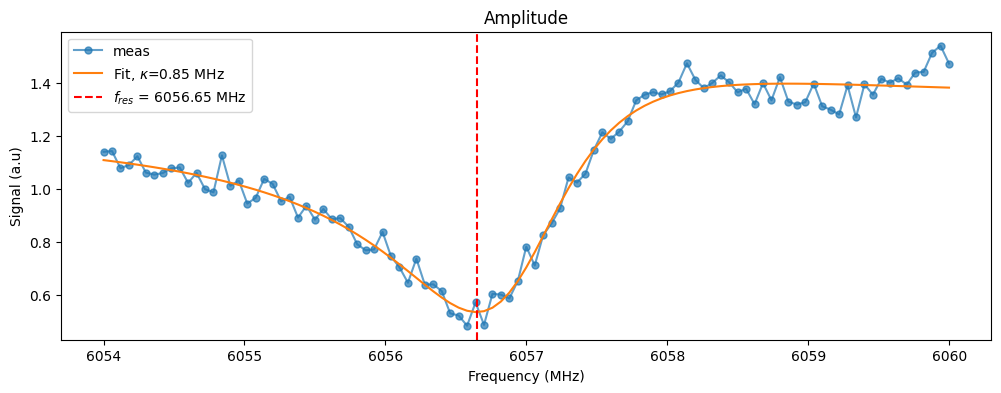

In [175]:
pyavg = 20

prog = SingleToneSpectroscopyProgramEF(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

f_res = resonator_analyze(freqs, res_onetone)
config['f_res_ef'] = f_res


# qb ef

In [777]:
class PulseProbeSpectroscopyProgram_EF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        self.add_gauss(ch=res_ch, name="gaus", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope='gaus',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        # self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
        #               alpha=cfg['alpha'], delta=cfg['delta']
        #               )
        self.add_pulse(ch=qubit_ch, name="qubit_ge_pi_pulse",
                       style="arb",
                       envelope='ramp',
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['pi_gain'],
                      )
        self.add_pulse(ch=qubit_ch, name="qubit_ef_pulse",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ef'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_ge_pi_pulse", t=0)
        self.delay_auto(0.01)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_ef_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [778]:
cemter = f_ge-200

START_FREQ = cemter - 100# [MHz]
STOP_FREQ = cemter + 100  # [MHz]
STEPS = 100
config.update({'qmixer_freq':cemter, 'qubit_gain':0.1, 'res_gain':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    ## Qubit Params. ##
    'f_ef': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'probe_len':1
     }

run_cfg = {**config, **expt_cfg}

run_cfg['f_res'] = 6054.42
run_cfg['ro_len'] = 2.4
run_cfg['res_gain'] = 0.89
run_cfg['trig_time'] = 0.4

  0%|          | 0/50 [00:00<?, ?it/s]

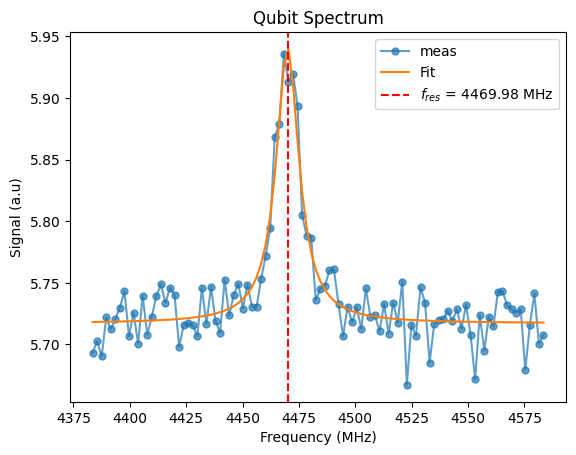

In [779]:
pyavg = 50
qspec=PulseProbeSpectroscopyProgram_EF(soccfg, reps=100, final_delay=config['relax_delay'], cfg=run_cfg)
iq_list = qspec.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_ef_pulse', "freq", as_array=True)

f_ef = spectrum_analyze(freqs, (iq_list[0][0].dot([1,1j])))
config['f_ef'] = f_ef


# Drag

In [793]:
class DragProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)


        # self.add_loop("dragloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        # self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                      alpha=cfg['alpha'], delta=cfg['delta']
                      )
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi2_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="drag", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['case']==1:
            self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)  
            self.delay_auto(0.01)
            self.pulse(ch=self.cfg["qubit_ch"], name="y90", t=0)
        elif self.cfg['case']==2:
            self.pulse(ch=self.cfg["qubit_ch"], name="y90", t=0)  
            self.delay_auto(0.01)
            self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)
            
        self.delay_auto(0.01, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

START_alpha= 0 # [us]
STOP_alpha = 0.01 # [us]
STEPS = 30

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'delta': round(f_ge-f_ef, 2),
    'case':1

    }

run_cfg = {**config, **expt_cfg}

In [608]:
alpha = np.linspace(-2, 4, 41)
run_cfg['case']=1
iq=[]
for i in tqdm(alpha):
    run_cfg['alpha'] = i
    drag=DragProgram(soccfg, reps=100, final_delay=config['relax_delay'], cfg=run_cfg)
    iq_list = drag.acquire(soc, soft_avgs=pyavg, progress=False)
    iq.append(iq_list[0][0].dot([1,1j]))

run_cfg['case']=2
iq2=[]
for i in tqdm(alpha):
    run_cfg['alpha'] = i
    drag=DragProgram(soccfg, reps=100, final_delay=config['relax_delay'], cfg=run_cfg)
    iq_list = drag.acquire(soc, soft_avgs=pyavg, progress=False)
    iq2.append(iq_list[0][0].dot([1,1j]))

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

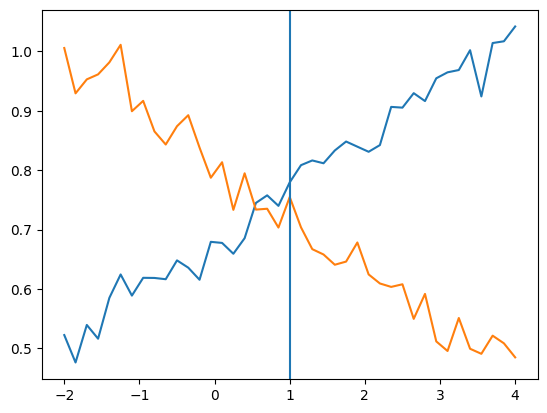

In [609]:
plt.plot(alpha, np.abs(iq))
plt.plot(alpha, np.abs(iq2))
plt.axvline(1)

In [ ]:
class DragProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)


        # self.add_loop("dragloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        # self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                      alpha=cfg['alpha'], delta=cfg['delta']
                      )
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="mx180", 
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )

        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="drag", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['case']==1:
            for _ in range(int(self.cfg['iter'])):
                self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)  
                self.delay_auto(0.01)
                self.pulse(ch=self.cfg["qubit_ch"], name="mx180", t=0)
                self.delay_auto(0.01)
        elif self.cfg['case']==2:
            for _ in range(int(self.cfg['iter'])):
                self.pulse(ch=self.cfg["qubit_ch"], name="x180", t=0)  
                self.delay_auto(0.01)
                self.pulse(ch=self.cfg["qubit_ch"], name="mx180", t=0)
                self.delay_auto(0.01)

        self.delay_auto(0.01, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


run_cfg = {**config, **expt_cfg}
run_cfg['delta'] =  round(f_ge-f_ef, 2)
run_cfg['alpha'] = 3.7
run_cfg['ro_len'] = 3
run_cfg['res_gain'] = 0.1
run_cfg['case']=1

In [799]:
iter = np.arange(1, 15, 1)
alpha=np.arange(-2, 3, 0.1)
iq=[]

for i in tqdm(iter, desc="iter sweep"):
    run_cfg['iter'] = i
    z=[]
    for j in tqdm(alpha, desc='alpha sweep', leave=False):
        run_cfg['alpha']=j
        drag=DragProgram(soccfg, reps=100, final_delay=config['relax_delay'], cfg=run_cfg)
        iq_list = drag.acquire(soc, soft_avgs=30, progress=False)
        z.append(iq_list[0][0].dot([1,1j]))
    iq.append(z)


iter sweep:   0%|          | 0/14 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

...

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

alpha sweep:   0%|          | 0/50 [00:00<?, ?it/s]

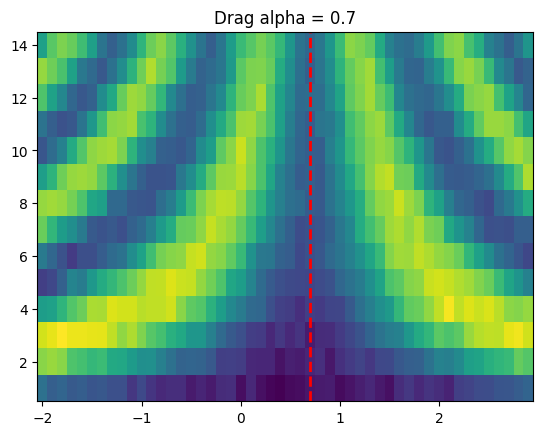

In [802]:
plt.pcolormesh(alpha, iter, np.abs(iq))
z=0
for i in range(len(iq)):
    z+=np.abs(iq[i])
plt.axvline(alpha[np.argmin(z)], color='r', ls='--', lw=2)
plt.title(f'Drag alpha = {alpha[np.argmin(z)]:.1f}')

config['alpha'] = round(alpha[np.argmin(z)],2)
config['delta'] =  round(f_ge-f_ef, 2)
run_cfg['alpha'] = round(alpha[np.argmin(z)],2)
run_cfg['delta'] =  round(f_ge-f_ef, 2)

In [883]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12\Q1Track'

In [884]:
data_path = data_path


exp_name = f"Drag calibrate"
file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Drag coefficient', 'unit': "alpah",
                'values': alpha},
        y_info={'name': 'pi-pi inter', 'unit': "#",
                'values': iter},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values': np.array(iq)},
        comment=f'',
        tag='Drag'
)

# Rabi ef

In [804]:
class AmplitudeRabiProgramEF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        self.add_gauss(ch=res_ch, name="gaus", sigma=0.004, length=0.004*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_DRAG(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                      alpha=cfg['alpha'], delta=cfg['delta']
                      )
        self.add_gauss(ch=qubit_ch, name="ramp2", sigma=cfg['sigmaef'], length=cfg['sigmaef']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_ge_pi_pulse",
                       style="arb",
                       envelope='ramp',
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['pi_gain'],
                      )
        self.add_pulse(ch=qubit_ch, name="qubit_ef_pulse",
                       style="arb", 
                       envelope='ramp',
                       freq=cfg['f_ef'], 
                       phase= 0,
                       gain=cfg['qubit_ef_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_ge_pi_pulse", t=0)
        self.delay_auto(0.01)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_ef_pulse", t=0)
        self.delay_auto(0.01)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [805]:
START_GAIN = 0.01 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 50


config.update({'relax_delay':50, 'qb_pulse_style':'arb', 'sigma':0.02, 'sigmaef':0.05, 'nzq':2})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    "qubit_ef_gain":QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'ro_len':0.2,
     }
run_cfg = {**config, **expt_cfg}




  0%|          | 0/20 [00:00<?, ?it/s]

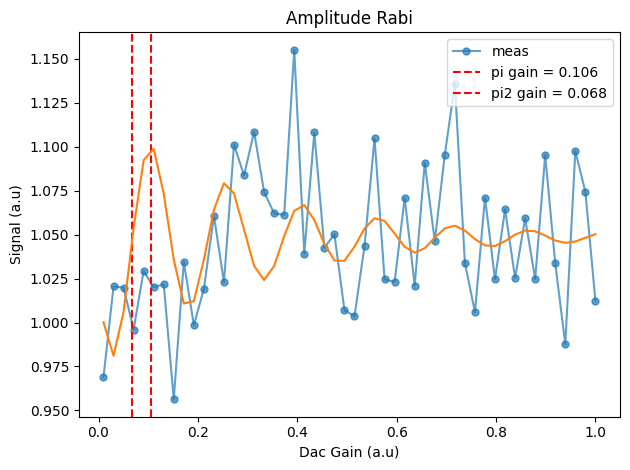

In [806]:
pyavg = 20

amp_rabi=AmplitudeRabiProgramEF(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True)
gains = amp_rabi.get_pulse_param('qubit_ef_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['ef_pi_gain'], config['ef_pi2_gain'] = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=None)

In [569]:
## Using the Dynamically Configured Readout Channel ##
class SingleToneSpectroscopyProgramGEF(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                    alpha=cfg['alpha'], delta=cfg['delta']
                    )
        self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                    style="arb", 
                    envelope="drag", 
                    freq=cfg['f_ge'],
                    phase=cfg['qubit_phase'],
                    gain=cfg['pi_gain'], 
                    )
        
        self.add_gauss(ch=qubit_ch, name="ramp2", sigma=cfg['sigmaef'], length=cfg['sigmaef']*5, even_length=True)
        self.add_pulse(ch=qubit_ch, name="qubit_ef_pulse",
                       style="arb", 
                       envelope='ramp2',
                       freq=cfg['f_ef'], 
                       phase= 0,
                       gain=cfg['ef_pi_gain'],
                      )


    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['qubit_ch'], name="qubit_pulse", t=0)
        self.delay_auto(0.01)
        self.pulse(ch=cfg['qubit_ch'], name="qubit_ef_pulse", t=0)
        self.delay_auto(0.01)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


  0%|          | 0/20 [00:00<?, ?it/s]

6055.35

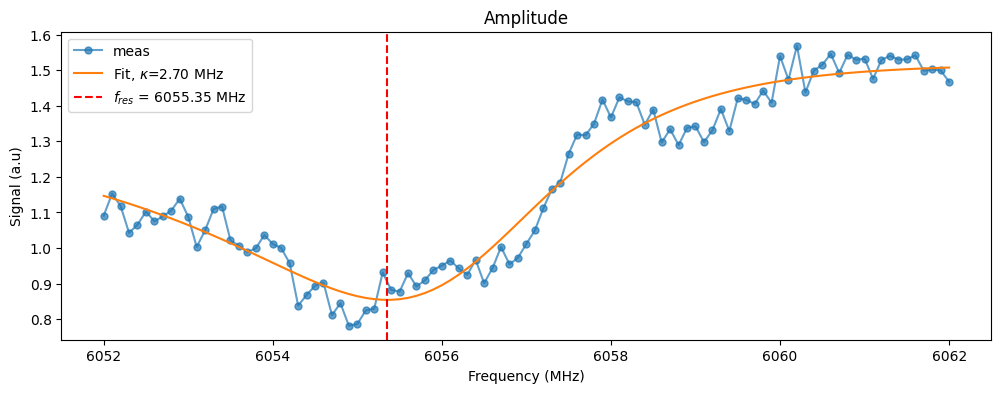

In [ ]:
START_FREQ = r - 5 # [MHz]
STOP_FREQ =  r + 5 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.1,
    'ro_len': 1
}
run_cfg = {**config, **exp_cfg}

run_cfg['delta'] =  round(f_ge-f_ef, 2)
run_cfg['alpha'] = 3.7

pyavg = 20

prog = SingleToneSpectroscopyProgramGEF(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

resonator_analyze(freqs, res_onetone)



# Single Shot

In [808]:
# Separate g and e per each experiment defined.

class SingleShotProgram_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots

        self.add_gauss(ch=res_ch, name="gaus", sigma=0.008, length=0.008*5, even_length=True,)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                    #    envelope='gaus',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # no qubit pulse
        self.delay_auto(0.01, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


class SingleShotProgram_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots
        self.add_gauss(ch=res_ch, name="gaus", sigma=cfg['res_sig'], length=cfg['res_sig']*5, even_length=True,)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                    #    envelope='gaus',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        if cfg['qb_pulse_style']=='arb':
            self.add_DRAG(ch=qubit_ch, name="drag", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True,
                        alpha=cfg['alpha'], delta=cfg['delta']
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                        style="arb", 
                        envelope="drag", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase'],
                        gain= cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="flat_top", 
                        envelope="ramp", 
                        length=cfg['flat_top_len'], 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.02, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [816]:
run_cfg['f_res']=6059

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

g unrotated averages:
I 5.463179804560261 +/- 3.4319897241890565 	 Q 7.672527035830618 +/- 1.953875767605185 	 Amp 9.931085195440012 +/- 2.384058622516048
Rotated (theta=2.77267433099935):
I -7.862370861546482 +/- 3.5875319539549544 	 Q -5.186244221786292 +/- 1.650999231231249 	 Amp 9.418811214399982 +/- 2.384058622516048
e unrotated averages:
I -0.08019413680781756 +/- 3.9292210229173503 	 Q 5.529351791530945 +/- 2.304063167297587 	 Amp 6.610079078457885 +/- 2.763060230333614
Rotated (theta=2.77267433099935):
I -1.919123030468122 +/- 4.096717226081373 	 Q -5.186244221786289 +/- 1.991078324768063 	 Amp 5.529933302860426 +/- 2.763060230333614


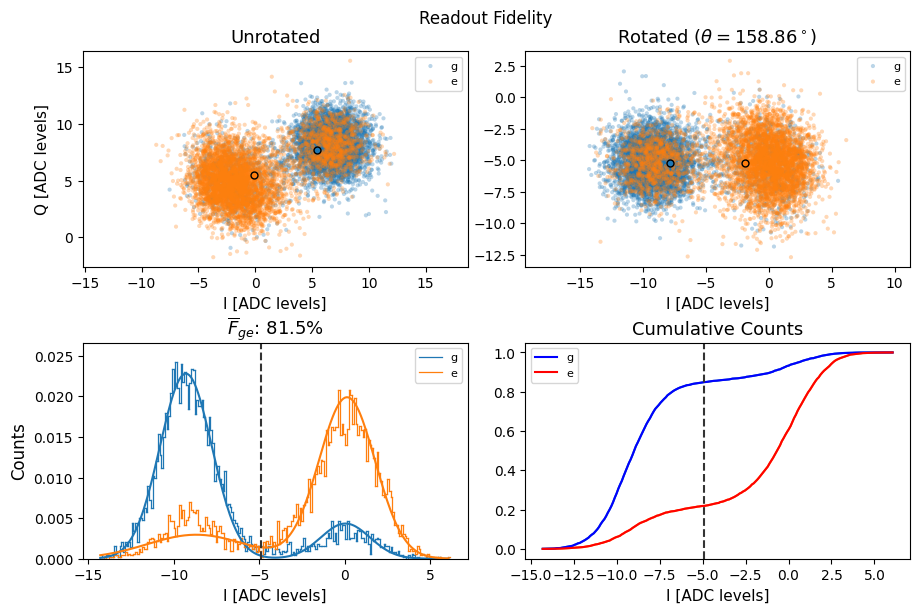

fidelity:[0.8145] 
thressholds:[-4.891452869031131] 
theta:158.8625371305218


In [881]:
SHOTS = 5000
run_cfg['res_sig'] = 0.004
run_cfg['steps'] = SHOTS


# run_cfg['f_res'] = 6054.42
# run_cfg['ro_len'] = 1.4
# run_cfg['res_gain'] = 0.3
# run_cfg['trig_time'] = 0.4

run_cfg['f_res'] = 6053.4#6054.2
run_cfg['ro_len'] = 1
run_cfg['res_gain'] = 0.85
run_cfg['trig_time'] = 0.4
6053.4
ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=True)

ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=True)

# ssp_f = SingleShotProgram_f(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
# iq_list_f = ssp_f.acquire(soc, soft_avgs=1, progress=True)

I_g = iq_list_g[0][0].T[0]
Q_g = iq_list_g[0][0].T[1]
I_e = iq_list_e[0][0].T[0]
Q_e = iq_list_e[0][0].T[1]


data={
    "Ig":I_g,
    "Qg": Q_g,
    "Ie": I_e,
    "Qe": Q_e,
    # "If": I_f,
    # "Qf": Q_f
}
f = histplot(data, fid_avg=True, fit=True, gauss_overlap=False)
single_shot = np.array((I_g+1j*Q_g, I_e+1j*Q_e))

g unrotated averages:
I 5.463179804560261 +/- 3.4319897241890565 	 Q 7.672527035830618 +/- 1.953875767605185 	 Amp 9.931085195440012 +/- 2.384058622516048
Rotated (theta=2.77267433099935):
I -7.862370861546482 +/- 3.5875319539549544 	 Q -5.186244221786292 +/- 1.650999231231249 	 Amp 9.418811214399982 +/- 2.384058622516048
e unrotated averages:
I -0.08019413680781756 +/- 3.9292210229173503 	 Q 5.529351791530945 +/- 2.304063167297587 	 Amp 6.610079078457885 +/- 2.763060230333614
Rotated (theta=2.77267433099935):
I -1.919123030468122 +/- 4.096717226081373 	 Q -5.186244221786289 +/- 1.991078324768063 	 Amp 5.529933302860426 +/- 2.763060230333614


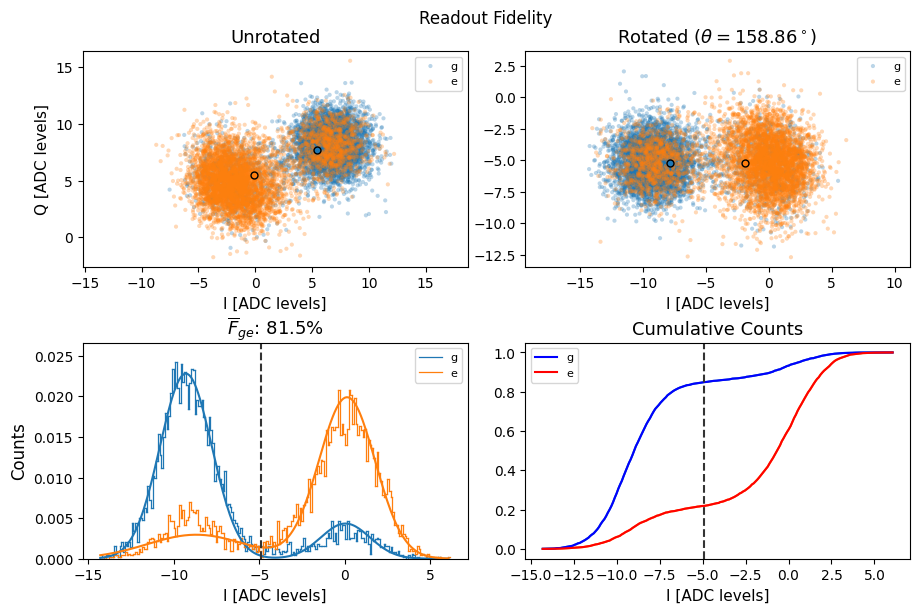

fidelity:[0.8145] 
thressholds:[-4.891452869031131] 
theta:158.8625371305218


In [945]:
data={
    "Ig":I_g,
    "Qg": Q_g,
    "Ie": I_e,
    "Qe": Q_e,
    # "If": I_f,
    # "Qf": Q_f
}
f = histplot(data, fid_avg=True, fit=True, gauss_overlap=False)

In [946]:

g = iq_list_g[0][0].dot([1,1j])
e = iq_list_e[0][0].dot([1,1j])

data={'g':g, 'e': e}


C:\Users\QEL\AppData\Local\Temp\ipykernel_20400\3165489059.py:130: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.

C:\Users\QEL\AppData\Local\Temp\ipykernel_20400\3165489059.py:130: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



Confusion matrix (aligned):
 [[0.848 0.152]
 [0.221 0.779]]
Fidelity per state: [0.848 0.779]
Average fidelity: 0.814


[0.814, -4.399044609828468, -2.8055303334409905]

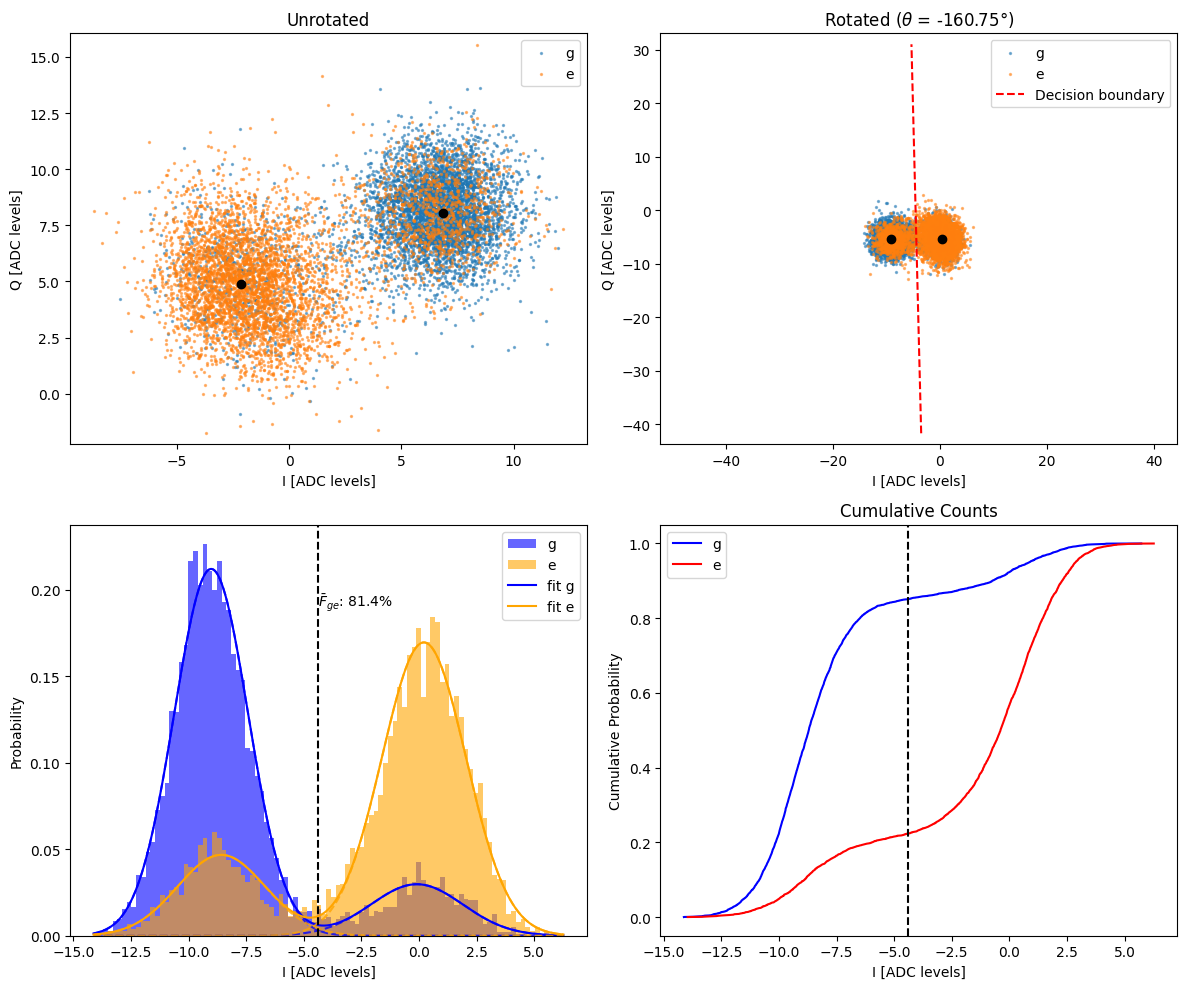

In [948]:
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment
from scipy.stats import norm
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt


def mode_2d_density_max(points, gridsize=100):
    kde = gaussian_kde(points.T)
    x, y = np.linspace(points[:, 0].min(), points[:, 0].max(), gridsize), np.linspace(points[:, 1].min(), points[:, 1].max(), gridsize)
    xx, yy = np.meshgrid(x, y)
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(grid_coords)
    max_idx = np.argmax(density)
    return grid_coords[:, max_idx] 


def ss_ge(data):
    numbins = 200
    g = np.column_stack([data['g'].real, data['g'].imag])
    e = np.column_stack([data['e'].real, data['e'].imag])

    mu_g = mode_2d_density_max(g)
    mu_e = mode_2d_density_max(e)
    vec = mu_e - mu_g
    theta = np.arctan2(vec[1], vec[0])

    Ig, Qg = g[:, 0], g[:, 1]
    Ie, Qe = e[:, 0], e[:, 1]
    best_theta = theta
    I_tot = np.concatenate((Ie, Ig))
    span = (np.max(I_tot) - np.min(I_tot))/2
    midpoint = (np.max(I_tot) + np.min(I_tot))/2
    xlims = [midpoint - span, midpoint + span]
    ng, _ = np.histogram(Ig, bins=numbins, range=xlims)
    ne, _ = np.histogram(Ie, bins=numbins, range=xlims)
    contrast = np.abs(((np.cumsum(ng) - np.cumsum(ne)) /
                      (0.5 * ng.sum() + 0.5 * ne.sum())))
    best_fid = np.max(contrast)

    for theta_i in np.linspace(theta - np.pi/12, theta + np.pi/12, 10):
        Ig_new = Ig * np.cos(theta_i) - Qg * np.sin(theta_i)
        Ie_new = Ie * np.cos(theta_i) - Qe * np.sin(theta_i)
        I_tot_new = np.concatenate((Ie_new, Ig_new))
        span = (np.max(I_tot_new) - np.min(I_tot_new))/2
        midpoint = (np.max(I_tot_new) + np.min(I_tot_new))/2
        xlims = [midpoint - span, midpoint + span]
        ng, _ = np.histogram(Ig_new, bins=numbins, range=xlims)
        ne, _ = np.histogram(Ie_new, bins=numbins, range=xlims)
        contrast = np.abs(((np.cumsum(ng) - np.cumsum(ne)) /
                          (0.5 * ng.sum() + 0.5 * ne.sum())))
        fid = np.max(contrast)
        if fid > best_fid:
            best_theta = theta_i
            best_fid = fid

    theta = best_theta  # update with optimal rotation
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    g_rot = (g) @ R
    e_rot = (e) @ R
    new_data = np.vstack([g_rot, e_rot])

    # GMM fit
    gmm = GaussianMixture(n_components=2, covariance_type='full')
    gmm.fit(new_data)
    prob_g = gmm.predict_proba(g_rot)
    prob_e = gmm.predict_proba(e_rot)
    avg_prob_g = prob_g.mean(axis=0)
    avg_prob_e = prob_e.mean(axis=0)

    conf_matrix = np.vstack([avg_prob_g, avg_prob_e])
    row_ind, col_ind = linear_sum_assignment(-conf_matrix)
    aligned = conf_matrix[:, col_ind]
    fidelity_per_state = np.diag(aligned)
    fidelity_avg = np.mean(fidelity_per_state)

    # GMM center & decision boundary
    mu0, mu1 = gmm.means_
    midpoint = (mu0 + mu1) / 2
    vec = mu1 - mu0
    normal = np.array([-vec[1], vec[0]]) #/ np.linalg.norm(vec)
    pt1 = midpoint + 4* normal
    pt2 = midpoint - 4* normal

    # Plotting
    plt.figure(figsize=(12, 10))

    # Unrotated scatter
    plt.subplot(2, 2, 1)
    plt.scatter(g[:, 0], g[:, 1], s=2, alpha=0.5, label='g')
    plt.scatter(e[:, 0], e[:, 1], s=2, alpha=0.5, label='e')
    plt.scatter(*mu_g, c='k', marker='o')
    plt.scatter(*mu_e, c='k', marker='o')
    plt.title("Unrotated")
    plt.xlabel("I [ADC levels]")
    plt.ylabel("Q [ADC levels]")
    plt.axis('equal')
    plt.legend()

    # Rotated scatter with boundary
    plt.subplot(2, 2, 2)
    plt.scatter(g_rot[:, 0], g_rot[:, 1], s=2, alpha=0.5, label='g')
    plt.scatter(e_rot[:, 0], e_rot[:, 1], s=2, alpha=0.5, label='e')
    plt.scatter(*mode_2d_density_max(g_rot), color='black', marker='o')
    plt.scatter(*mode_2d_density_max(e_rot), color='black', marker='o')
    plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], 'r--', label='Decision boundary')
    plt.title(f"Rotated ($\\theta$ = {np.degrees(theta):.2f}°)")
    plt.xlabel("I [ADC levels]")
    plt.ylabel("Q [ADC levels]")
    plt.axis('equal')
    plt.legend()

    # Projected hist with Gauss fit
    plt.subplot(2, 2, 3)
    bins = np.linspace(min(new_data[:, 0]), max(new_data[:, 0]), 100)
    plt.hist(g_rot[:, 0], bins=bins, density=True, alpha=0.6, label='g', color='blue')
    plt.hist(e_rot[:, 0], bins=bins, density=True, alpha=0.6, label='e', color='orange')
    x = np.linspace(bins[0], bins[-1], 1000)
    def plot_double_gaussian(x_data, color, label):
        gmm1d = GaussianMixture(n_components=2)
        gmm1d.fit(x_data.reshape(-1, 1))
        weights = gmm1d.weights_
        means = gmm1d.means_.flatten()
        covars = gmm1d.covariances_.flatten()
        
        for w, m, v in zip(weights, means, covars):
            plt.plot(x, w * norm.pdf(x, m, np.sqrt(v)), color=color, linestyle='--', alpha=0.8)
        total_pdf = np.sum(w * norm.pdf(x, m, np.sqrt(v)) for w, m, v in zip(weights, means, covars))
        plt.plot(x, total_pdf, color=color, label=label)

    plot_double_gaussian(g_rot[:, 0], 'blue', 'fit g')
    plot_double_gaussian(e_rot[:, 0], 'orange', 'fit e')
    plt.axvline(x=midpoint[0], color='k', linestyle='--')
    plt.text(midpoint[0], plt.ylim()[1]*0.8, f"$\\bar{{F}}_{{ge}}$: {fidelity_avg*100:.1f}%", fontsize=10)
    plt.xlabel("I [ADC levels]")
    plt.ylabel("Probability")
    plt.legend()

    # CDF plot
    plt.subplot(2, 2, 4)
    g_sorted = np.sort(g_rot[:, 0])
    e_sorted = np.sort(e_rot[:, 0])
    g_cdf = np.arange(len(g_sorted)) / len(g_sorted)
    e_cdf = np.arange(len(e_sorted)) / len(e_sorted)
    plt.plot(g_sorted, g_cdf, label='g', color='blue')
    plt.plot(e_sorted, e_cdf, label='e', color='red')
    plt.axvline(x=midpoint[0], color='k', linestyle='--')
    plt.xlabel("I [ADC levels]")
    plt.ylabel("Cumulative Probability")
    plt.title("Cumulative Counts")
    plt.legend()
    plt.tight_layout()

    print("Confusion matrix (aligned):\n", np.round(aligned, 3))
    print("Fidelity per state:", np.round(fidelity_per_state, 3))
    print("Average fidelity:", round(fidelity_avg, 3))

    return [round(fidelity_avg, 3), midpoint[0], theta]

ss_ge(data)

In [935]:
import numpy as np
h = 6.62607015e-34  # Planck
kB = 1.380649e-23   # Boltzmann
freq = 4.68e9          # qubit frequency, Hz (5 GHz)

# 推估 population
P_g = (0.848 + 0.221) / 2
P_e = (0.152 + 0.779) / 2

# 保護：避免 log(0)
if P_e == 0 or P_g == 0:
    raise ValueError("Invalid zero probability for log")

# 計算有效溫度
T = (h * freq) / (kB * np.log(P_g / P_e))  # in Kelvin
print(f"Effective temperature: {T:.2f} K")

Effective temperature: 1.62 K


In [ ]:
filename = 'q2 single shot 98.9'

file_path = get_next_filename_labber(data_path, filename)
dict_val = yml_comment(run_cfg)
hdf5_generator(
    filepath = file_path,
    x_info = {'name':'shot', 'unit':"point", 'values':np.arange(SHOTS)},
    z_info = {'name': 'Signal','unit': 'a.u.','values': single_shot},
    y_info = {'name': 'ge', 'unit': '','values': np.array([0,1])},
    comment = f'{dict_val}', tag = f'SingleShot'
)

## Optimize

In [823]:
freq_steps = 20
freq_step_size = 0.2 # [MHz]
# freq_start = (config['f_res']-5) - ((freq_steps/2)*freq_step_size)
freq_start = (6054) - ((freq_steps/2)*freq_step_size)
gain_steps = 10
gain_step_size = 0.05 # [DAC units]
gain_start = 0.4


SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for gains in tqdm(range(gain_steps), desc='Gain loop', leave=False):
        run_cfg.update({
            ## Sweep Params: ##
            'steps': SHOTS, # Number of shot points (outer loop)
            'f_res': freq_start + freq_step_size*freqs, # [MHz]
            'res_phase': 0, # [deg]
            'res_gain': gain_start + gain_step_size*gains, # [DAC units]
            'res_len':5,
            'ro_len':1
            })

        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]

        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_20400\2856282888.py:39: UserWarning:

The following kwargs were not used by contour: 'interpolation'



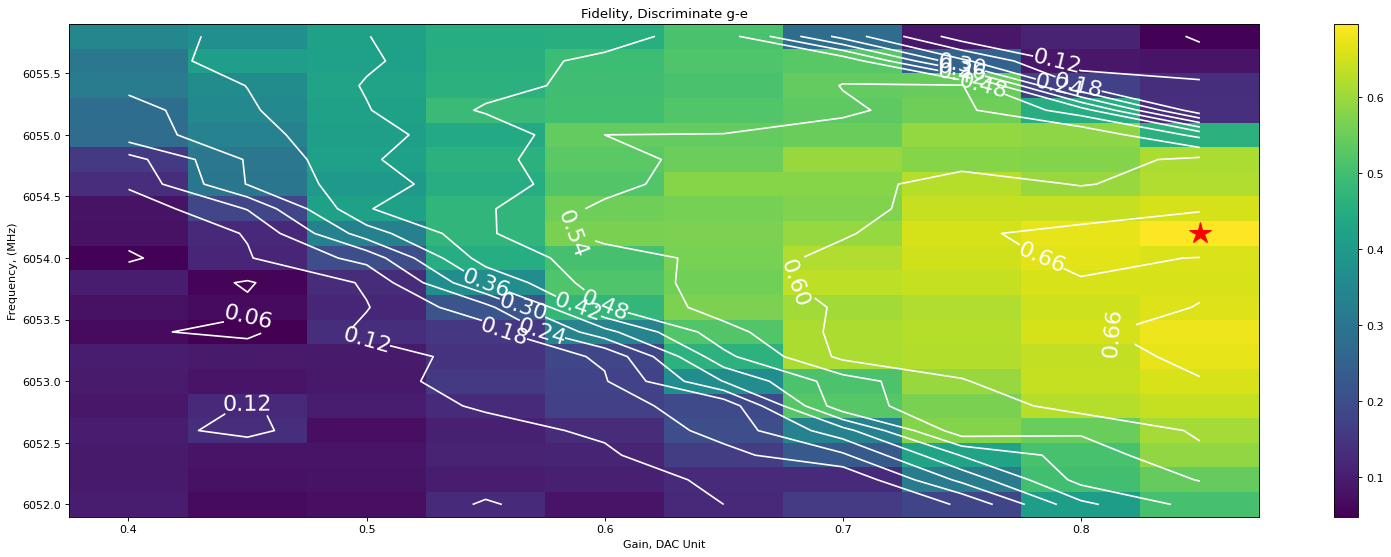

6054.2 0.8500000000000001


In [824]:
fid_Array =np.zeros([freq_steps,gain_steps])
for index_freq in range(freq_steps):
    for index_amp in range(gain_steps):

        I_g = I_g_array[index_freq][0][index_amp][0]
        Q_g = Q_g_array[index_freq][0][index_amp][0]
        I_e = I_e_array[index_freq][0][index_amp][0]
        Q_e = Q_e_array[index_freq][0][index_amp][0]


        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q) ** 2


        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom

        th_list = np.linspace(min(gstate), max(estate), 1000)
        gstate = gstate.reshape(1, -1)
        estate = estate.reshape(1, -1)
        th_list = th_list.reshape(-1, 1)

        g_cdf = np.sum(gstate < th_list, axis=1) / gstate.shape[1]
        e_cdf = np.sum(estate > th_list, axis=1) / estate.shape[1]
        fidelity = (g_cdf + e_cdf) / 2
        fid_Array[index_freq, index_amp] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
gains_list = np.zeros(gain_steps)
for gain in range(gain_steps):
    gains_list[gain] = gain_start + gain_step_size*gain
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(gains_list,freqs_list,fid_Array)
figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"Gain, DAC Unit")
plt.ylabel(r"Frequency, (MHz)")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_gain_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_gain = gains_list[max_gain_idx]
plt.plot(max_gain, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.title(r"Fidelity, Discriminate g-e")
plt.colorbar(figA)
plt.show()
print(max_freq, max_gain)
#plt.savefig("FidwithoutJPA.png",dpi=300,bbox_inches='tight')

In [825]:
freq_steps = 20

freq_step_size = 0.1 # [MHz]
freq_start = (6054.2 ) - ((freq_steps/2)*freq_step_size)
length_steps = 15
length_step_size = 0.1 # [us units]
length_start = 0.7
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for lengths in tqdm(range(length_steps), desc='ro len loop', leave=False):
        run_cfg.update({'steps': SHOTS,
                        'f_res': freq_start + freq_step_size*freqs,
                        'res_len': 10,
                        'ro_len': length_start + length_step_size*lengths,
                        'res_gain':0.85
                        })


        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

...

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/15 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_20400\2642240738.py:38: UserWarning:

The following kwargs were not used by contour: 'interpolation'



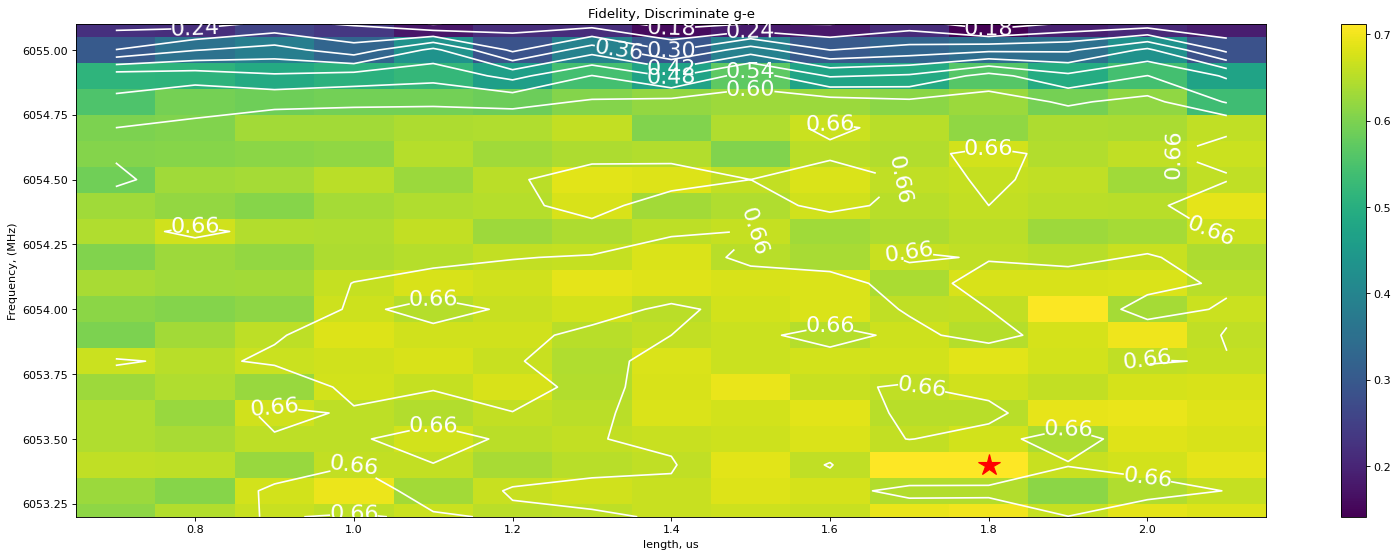

6053.4 1.8


In [826]:
fid_Array = np.zeros((freq_steps, length_steps))

for index_freq in range(freq_steps):
    for index_length in range(length_steps):
        I_g = I_g_array[index_freq][0][index_length][0]
        Q_g = Q_g_array[index_freq][0][index_length][0]
        I_e = I_e_array[index_freq][0][index_length][0]
        Q_e = Q_e_array[index_freq][0][index_length][0]

        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q)**2

        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom


        th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
        g_proj = np.array(gstate).reshape(1, -1)
        e_proj = np.array(estate).reshape(1, -1)

        g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
        e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
        fidelity = (g_cdf + e_cdf) / 2

        fid_Array[index_freq, index_length] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
lengths_list = np.zeros(length_steps)
for length in range(length_steps):
    lengths_list[length] = length_start + length_step_size*length
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(lengths_list,freqs_list,fid_Array)
figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"length, us")
plt.ylabel(r"Frequency, (MHz)")
plt.title(r"Fidelity, Discriminate g-e")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_length_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_length = lengths_list[max_length_idx]
plt.plot(max_length, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.colorbar(figA)
plt.show()
print(max_freq, max_length)